Este proyecto fue realizado con datos de Kaggle sobre las ventas de la tienda Rossman en el cual intentaremos predecir ventas ocupando el modelo Propthet de Facebook

In [1]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.
Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_csv('train.csv', low_memory=False)
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


Trazaremos las ventas de la tienda 1

<Axes: title={'center': 'Store 1 Sales'}>

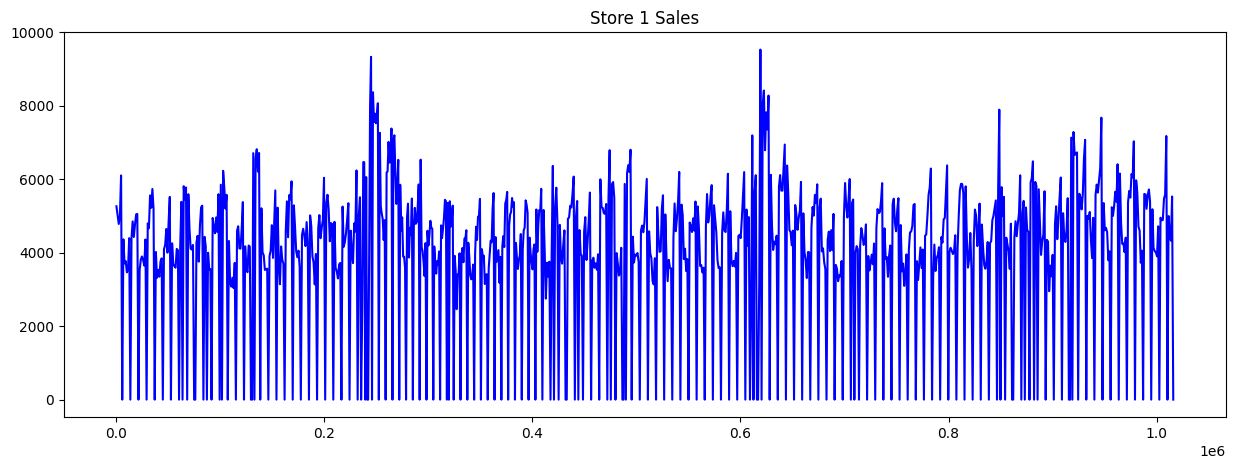

In [3]:
df[df['Store'] == 1]['Sales'].plot(figsize=(15, 5), title='Store 1 Sales', color='blue')

Vemos un comportamiento con estacionalidades y algunos puntos que se van a 0, por lo tanto veremos cuantos valores se van a 0

In [4]:
(df[df['Store'] == 1]['Sales']==0).sum()

np.int64(161)

Seleccionaremos los datos solo de la tienda 1

In [5]:
store1 = df[df['Store'] == 1].copy()

Probablemente se van a 0 las ventas porque esos dias la tienda no esta abierta, por lo cual graficaremos las ventas solo de los días que la tienda esta abierta

<Axes: title={'center': 'Store 1 Sales'}>

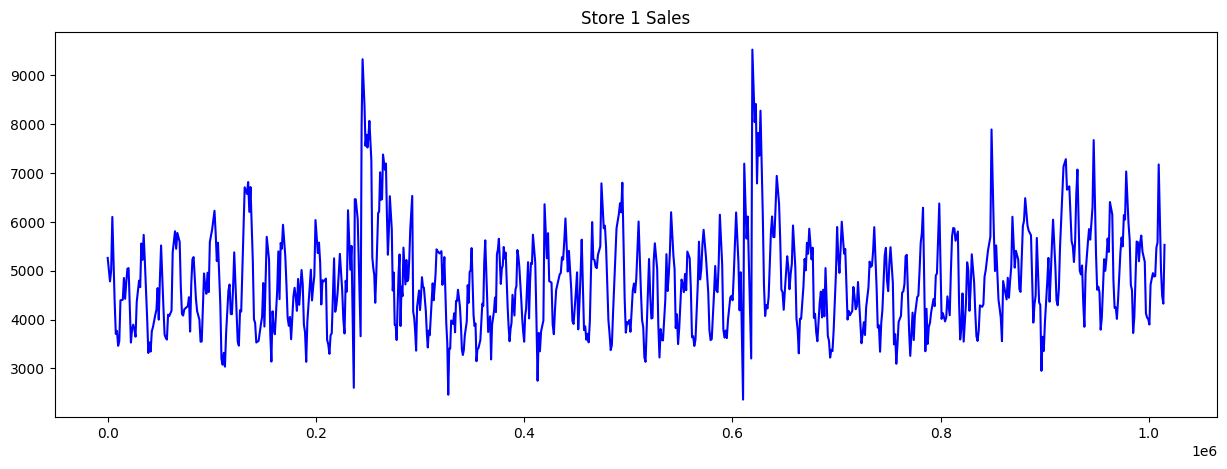

In [6]:
store1[store1['Open'] > 0]['Sales'].plot(figsize=(15, 5), title='Store 1 Sales', color='blue')

Hay varias formas de comprobar donde las ventas son 0

In [7]:
sales0 = store1[store1['Sales'] == 0].index
customers0 = store1[store1['Customers'] == 0].index
store_closed = store1[store1['Open'] == 0].index
print(np.all(sales0 == customers0))
print(np.all(store_closed == customers0))

True
True


In [8]:
store1.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1115,1,4,2015-07-30,5020,546,1,1,0,1
2230,1,3,2015-07-29,4782,523,1,1,0,1
3345,1,2,2015-07-28,5011,560,1,1,0,1
4460,1,1,2015-07-27,6102,612,1,1,0,1


Convertimos la fecha a formato fecha

In [9]:
store1['Date'] = pd.to_datetime(store1['Date'])

Ahora establecemos las fechas como indice, solo para verlo de forma grafica, ya que para el modelo de prophet necesitamos la fecha como columna

In [10]:
store1.set_index('Date', inplace=True)

In [11]:
store1.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-30,1,4,5020,546,1,1,0,1
2015-07-29,1,3,4782,523,1,1,0,1
2015-07-28,1,2,5011,560,1,1,0,1
2015-07-27,1,1,6102,612,1,1,0,1


<Axes: title={'center': 'Store 1 Sales'}, xlabel='Date'>

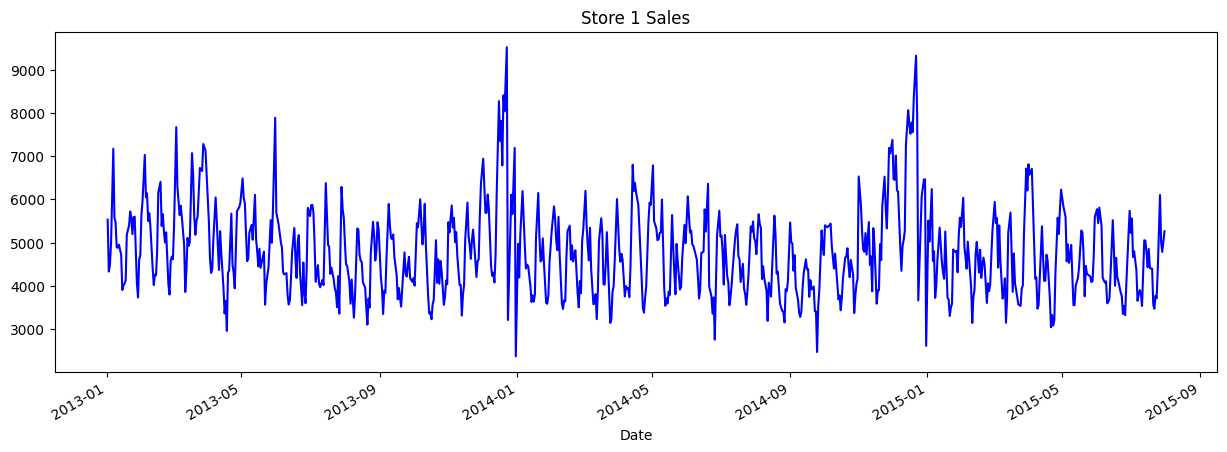

In [12]:
store1[store1['Customers'] > 0]['Sales'].plot(figsize=(15, 5), title='Store 1 Sales', color='blue')

Ahora lo dejaremos en el formato que necesitamos para el modelo prophet

In [13]:
df_p = store1[['Sales']].copy()

In [14]:
df_p['Date'] = df_p.index

In [16]:
df_p.head()

,Sales,Date
Date,,
2015-07-31,5263,2015-07-31
2015-07-30,5020,2015-07-30
2015-07-29,4782,2015-07-29
2015-07-28,5011,2015-07-28
2015-07-27,6102,2015-07-27


In [17]:
df_p.tail()

,Sales,Date
Date,,
2013-01-05,4997,2013-01-05
2013-01-04,4486,2013-01-04
2013-01-03,4327,2013-01-03
2013-01-02,5530,2013-01-02
2013-01-01,0,2013-01-01


In [19]:
df_p.sort_index(inplace=True)

In [20]:
df_p.head()

,Sales,Date
Date,,
2013-01-01,0,2013-01-01
2013-01-02,5530,2013-01-02
2013-01-03,4327,2013-01-03
2013-01-04,4486,2013-01-04
2013-01-05,4997,2013-01-05


In [21]:
df_p.tail()

,Sales,Date
Date,,
2015-07-27,6102,2015-07-27
2015-07-28,5011,2015-07-28
2015-07-29,4782,2015-07-29
2015-07-30,5020,2015-07-30
2015-07-31,5263,2015-07-31


Cambiamos el nombre de las columnas

In [22]:
df_p.columns = ['y', 'ds']

In [ ]:
m = Prophet()

In [ ]:
m.fit(df_p)

In [ ]:
future = m.make_future_dataframe(periods=365)

In [ ]:
future.head()

In [ ]:
future.tail()